In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import sys
import os
from pathlib import Path

In [2]:
# Add src to path for imports
os.chdir(os.path.dirname(os.path.abspath('.'))) 

In [3]:
from src.battery.battery import BatteryConfig
from src.battery.lp_optimizer import LPOptimizer
from src.battery.fetcher import load_sample_prices, compute_price_statistics

── 0. Configuration ─────────────────────────────────────────────────────────

In [4]:
battery = BatteryConfig(
    power_mw=100.0,
    capacity_mwh=400.0,
    rte_charge=0.93,
    rte_discharge=0.95,
    degradation_cost=10.0,
    soc_min_pct=0.05,
    soc_max_pct=0.95,
    soc_initial_pct=0.50,
)

In [5]:
optimizer = LPOptimizer(battery, dt_hours=1.0)

In [6]:
print("Battery configuration:")
print(f"  {battery}")
print(f"  Minimum profitable spread: ${battery.minimum_profitable_spread():.2f}/MWh")
print(f"  Usable capacity: {battery.usable_capacity_mwh:.0f} MWh")

Battery configuration:
  BatteryConfig(100.0MW / 400.0MWh, RTE=88.3%, degradation=$10.0/MWh)
  Minimum profitable spread: $21.32/MWh
  Usable capacity: 360 MWh


── 1. Load Prices ────────────────────────────────────────────────────────────

In [ ]:
from src.battery.fetcher import fetch_caiso_prices, fetch_ercot_prices
# prices_ercot = fetch_ercot_prices("2025-01-01", "2025-12-31")
# ERCOT API does not provide historical data that far back

prices_caiso = fetch_caiso_prices("2025-01-01", "2025-04-01")

Loading CAISO data from cache: c:\Users\grego\Documents\Github\Battery Optimiser\data\processed\caiso_TH_NP15_GEN-APND_2025-01-01_2025-04-01.parquet


In [8]:
print(f"\nCAISO prices:")
print(f"  Min: ${prices_caiso.min():.1f}/MWh at hour {prices_caiso.idxmin().hour}")
print(f"  Max: ${prices_caiso.max():.1f}/MWh at hour {prices_caiso.idxmax().hour}")
print(f"  Spread: ${prices_caiso.max() - prices_caiso.min():.1f}/MWh")


CAISO prices:
  Min: $-38.5/MWh at hour 14
  Max: $91.7/MWh at hour 6
  Spread: $130.2/MWh


In [9]:
# NaN analysis
print(prices_caiso.resample('D').apply(lambda x: x.isna().sum()).value_counts())

LMP
0    90
Name: count, dtype: int64


── 2. Solve the LP ───────────────────────────────────────────────────────────

In [10]:
print("\nSolving LP for CAISO  day...")


Solving LP for CAISO  day...


In [11]:
result = optimizer.solve(prices_caiso.values)
print(f"Status: {result.status}")
print(f"Total revenue: ${result.total_revenue:.2f}")
print(f"Cycles: {result.n_cycles:.2f}")

Status: optimal
Total revenue: $604467.85
Cycles: 76.80


── 3. Plot: SOC + Price Overlay ─────────────────────────────────────────────

In [12]:
def plot_dispatch(prices: pd.Series, result, battery: BatteryConfig, title: str):
    """
    Standard dispatch visualization: prices on top, SOC on bottom.

    This is the primary diagnostic plot. For any result you generate,
    you should be able to look at this plot and understand why the battery
    made the decisions it did.
    """
    fig = plt.figure(figsize=(14, 8))
    gs = gridspec.GridSpec(3, 1, height_ratios=[2, 1.5, 1])

    hours = np.arange(len(prices))

    # Panel 1: Prices
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(hours, prices.values, 'k-', linewidth=2, label='Price')
    ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax1.fill_between(hours, prices.values, 0,
                     where=(prices.values < 0), alpha=0.3, color='red',
                     label='Negative price')
    ax1.set_ylabel('Price ($/MWh)')
    ax1.set_title(title)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    if result is not None:
        # Panel 2: Charge/Discharge
        ax2 = fig.add_subplot(gs[1], sharex=ax1)
        ax2.bar(hours, result.discharge_mw, color='green', alpha=0.7,
                label='Discharge (revenue)')
        ax2.bar(hours, -result.charge_mw, color='red', alpha=0.7,
                label='Charge (cost)')
        ax2.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
        ax2.set_ylabel('Power (MW)')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        # Panel 3: SOC
        ax3 = fig.add_subplot(gs[2], sharex=ax1)
        ax3.fill_between(range(len(result.soc_mwh)), result.soc_mwh,
                         battery.soc_min_mwh, alpha=0.5, color='blue')
        ax3.axhline(y=battery.soc_max_mwh, color='red', linestyle='--',
                    alpha=0.5, label=f'SOC max ({battery.soc_max_mwh:.0f} MWh)')
        ax3.axhline(y=battery.soc_min_mwh, color='orange', linestyle='--',
                    alpha=0.5, label=f'SOC min ({battery.soc_min_mwh:.0f} MWh)')
        ax3.set_ylabel('SOC (MWh)')
        ax3.set_xlabel('Hour')
        ax3.legend()
        ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig


Saved price plot to results/plots/01_caiso_prices.png


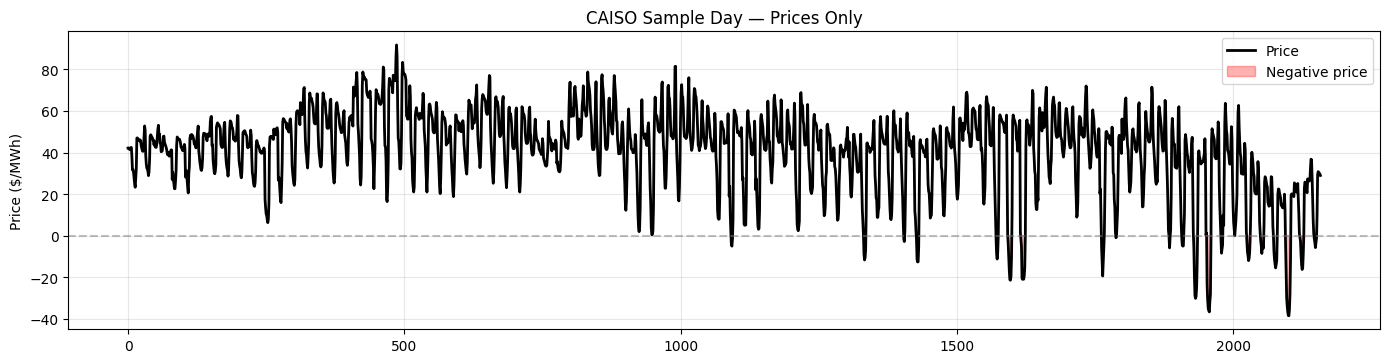

In [15]:
# Plot synthetic prices even before LP is implemented
fig = plot_dispatch(prices_caiso, result=None, battery=battery,
                    title="CAISO Sample Day — Prices Only")
plt.savefig("results/plots/01_caiso_prices.png", dpi=150, bbox_inches='tight')
print("\nSaved price plot to results/plots/01_caiso_prices.png")

── 4. Revenue Metrics ────────────────────────────────────────────────────────

In [16]:
print(f"\nRevenue metrics:")
print(f"  Total revenue: ${result.total_revenue:.2f}")
print(f"  Annualized ($/kW-yr): ${result.revenue_per_kw_yr:.2f}")
print(f"  Number of cycles: {result.n_cycles:.2f}")


Revenue metrics:
  Total revenue: $604467.85
  Annualized ($/kW-yr): $24.53
  Number of cycles: 76.80


In [17]:
# Price statistics (doesn't require LP)
print("\nCAISO price statistics:")
stats = compute_price_statistics(prices_caiso)
for k, v in stats.items():
    print(f"  {k}: {v:.2f}")


CAISO price statistics:
  mean_price: 40.89
  std_price: 19.98
  min_price: -38.47
  max_price: 91.71
  pct_negative: 5.00
  pct_above_100: 0.00
  pct_above_200: 0.00
  daily_spread_mean: 46.15
  daily_spread_p90: 66.46


── 5. CAISO vs ERCOT Comparison ─────────────────────────────────────────────

In [ ]:
# # TO DO
# result_ercot = optimizer.solve(prices_ercot.values)
# result_caiso = optimizer.solve(prices_caiso.values)

# print(f"\nMarket comparison (single day):")
# print(f"  {'Metric':<30} {'ERCOT':>12} {'CAISO':>12}")
# print(f"  {'-'*54}")
# print(f"  {'Revenue ($)':<30} {result_ercot.total_revenue:>12.2f} {result_caiso.total_revenue:>12.2f}")
# print(f"  {'Cycles':<30} {result_ercot.n_cycles:>12.2f} {result_caiso.n_cycles:>12.2f}")
# print(f"  {'Price spread ($/MWh)':<30} ...")
